# Energy Optimizer — Interactive Visualization

Runs the MILP HiGHS optimizer against `config.yaml` with live data from ioBroker.

**Four-step workflow — run cells in order:**

| Step | Cell | What it does |
|------|------|--------------|
| 1 | Configure | Set paths, cost basis, price tariff |
| 2 | Run optimizer | Fetch live data, build + solve MILP, print summary |
| 3 | Dispatch table | Per-step kW table for every battery |
| 4 | Diagram | Four-panel chart from the same optimizer result |

Steps 3 and 4 both read from the variables produced by Step 2, so table and diagram are always consistent with each other.


In [17]:
%matplotlib inline
import sys
from pathlib import Path

# Resolve repo root -- VS Code sets __vsc_ipynb_file__ to the notebook path.
# Fall back to cwd if that variable is absent.
try:
    _nb_path = Path(globals().get('__vsc_ipynb_file__') or __file__).resolve()
except NameError:
    _nb_path = Path().resolve() / 'visualize_optimizer.ipynb'

_nb_dir   = _nb_path.parent
repo_root = _nb_dir.parent if _nb_dir.name == 'notebooks' else _nb_dir

sys.path.insert(0, str(repo_root / 'src'))
sys.path.insert(0, str(repo_root / 'scripts'))

print(f'Repo root : {repo_root}')
print(f'Config    : {repo_root / "config.yaml"}')


Repo root : /Users/david/repos/energy-assistant
Config    : /Users/david/repos/energy-assistant/config.yaml


In [18]:
# ── Step 1: Configure ─────────────────────────────────────────────────────────

CONFIG_PATH  = repo_root / 'config.yaml'

# Set to a tariff ID (e.g. 'household') to pin the price source, or None to auto-detect.
PRICE_TARIFF = None

# Set to a file path string to also save a PNG, or None to skip saving.
SAVE_PATH    = None   # e.g. str(repo_root / 'optimizer_plan.png')

# ── Cost basis overrides ───────────────────────────────────────────────────────
# The price (€/kWh) at which energy CURRENTLY STORED was effectively "bought".
# Used as the minimum acceptable sell price (discharge threshold).
#
# None  → use the current spot price
# dict  → per-device override, e.g. PV-charged or cheap overnight energy
#
# Examples:
#   COST_BASIS = {"sma_battery": 0.12, "zendure": 0.08}  # charged cheap / from PV
#   COST_BASIS = {"sma_battery": 0.38}                    # override one device only
#   COST_BASIS = None                                      # always use spot price
COST_BASIS = {"sma_battery": 0.12, "zendure": 0.08}

# ── Terminal value overrides ───────────────────────────────────────────────────
# The expected FUTURE market value (€/kWh) of energy sitting in the batteries
# at the END of the planning horizon.  This controls PV recharge incentives:
#
#   The optimizer charges from PV only when:
#     terminal_value > export_price / η_c + degradation_cost
#                    ≈  0.082 / 0.95  + 0.059  =  0.145 €/kWh  (Zendure)
#                    ≈  0.082 / 0.95  + 0.079  =  0.165 €/kWh  (SMA)
#
# None  → auto-compute from forecast (70th-percentile of all horizon prices)
#         Typical result: ~0.35–0.40 €/kWh → PV charging enabled
# dict  → explicit per-device override
#
# Examples:
#   TERMINAL_VALUE = {"sma_battery": 0.30, "zendure": 0.25}  # explicit
#   TERMINAL_VALUE = None                                      # auto (recommended)
TERMINAL_VALUE = None


In [19]:
# ── Step 2: Run Optimizer ─────────────────────────────────────────────────────
# Fetches live prices, PV forecast, and battery SoC from ioBroker, then builds
# and solves the MILP.  All results are stored as kernel variables used by
# Steps 3 (table) and 4 (diagram).

import importlib, pulp
from datetime import datetime, timedelta, timezone
from energy_assistant.config.yaml import YamlConfigLoader
from energy_assistant.loader.device_loader import build as _build
from energy_assistant.core.models import (
    DeviceRole, DeviceState, ForecastPoint, ForecastQuantity, StorageConstraints,
)
from energy_assistant.core.optimizer import OptimizationContext
from energy_assistant.core.ledger import BatteryCostLedger
from energy_assistant.plugins._iobroker.pool import IoBrokerConnectionPool
from energy_assistant.core.plugin_registry import BuildContext

# Reload MILP modules first so code changes are picked up without a kernel restart.
# visualize_optimizer is reloaded after so it captures the updated optimizer class.
import energy_assistant.plugins.milp_highs.optimizer as _milp_mod
import energy_assistant.plugins.milp_highs as _milp_pkg
import visualize_optimizer as _vo
importlib.reload(_milp_mod)
importlib.reload(_milp_pkg)
importlib.reload(_vo)

from energy_assistant.plugins.milp_highs import MilpHigsOptimizer

# ── 1. Load config + build devices/tariffs ────────────────────────────────────
app_config = YamlConfigLoader(CONFIG_PATH).load()
device_registry, tariffs, _ = _build(app_config)

iobroker_pool = IoBrokerConnectionPool()
ctx = BuildContext(backends=app_config.backends, iobroker_pool=iobroker_pool, ha_client=None)
forecast_providers = _vo._build_forecast_providers(app_config, ctx)

# ── 2. Fetch with generous cap, then auto-detect actual horizon ───────────────
horizon_cap_h = int(app_config.optimizer.get("horizon_hours", 48))
horizon_cap   = timedelta(hours=horizon_cap_h)
now           = datetime.now(timezone.utc).replace(second=0, microsecond=0)

raw_prices, price_src = await _vo._fetch_raw_prices(tariffs, PRICE_TARIFF, horizon_cap)
raw_pv,    pv_src     = await _vo._fetch_raw_pv(forecast_providers, horizon_cap)

step_min  = _vo._detect_step_minutes(raw_prices, raw_pv)
step_td   = timedelta(minutes=step_min)
step_h    = step_min / 60.0

# Use the full extent of available data (capped at horizon_cap)
horizon   = _vo._infer_horizon(raw_prices, raw_pv, step_td, now, cap=horizon_cap)
horizon_h = int(horizon.total_seconds() / 3600)
timestamps = [now + step_td * i for i in range(int(horizon / step_td))]
prices    = _vo._align(raw_prices, timestamps)
pv_kw     = _vo._align(raw_pv, timestamps)

print(f"  Prices      : {price_src}")
print(f"  PV forecast : {pv_src}")
print(f"  Time step   : {step_min} min  →  {len(timestamps)} steps over {horizon_h} h")

# ── 3. Live SoC ───────────────────────────────────────────────────────────────
storage_devices = device_registry.by_role(DeviceRole.STORAGE)
storage_constraints: list[StorageConstraints] = []
device_states: dict[str, DeviceState] = {}

for dev in storage_devices:
    sc = getattr(dev, "storage_constraints", None)
    if sc is None:
        continue
    storage_constraints.append(sc)
    soc = await _vo._fetch_soc(dev)
    device_states[dev.device_id] = DeviceState(
        device_id=dev.device_id,
        soc_pct=soc if soc is not None else (sc.min_soc_pct + sc.max_soc_pct) / 2,
    )
    print(f"  SoC {dev.device_id:20s}: {device_states[dev.device_id].soc_pct:.1f} %")

# ── 4. Cost ledger ────────────────────────────────────────────────────────────
overrides    = COST_BASIS or {}
current_spot = prices[0] if prices else 0.25
ledger = BatteryCostLedger()
for sc in storage_constraints:
    stored = sc.capacity_kwh * (device_states[sc.device_id].soc_pct or 0) / 100
    basis  = overrides.get(sc.device_id, current_spot)
    ledger.initialise(sc.device_id, stored, basis)

baseline_kw = float(app_config.optimizer.get("baseline_load_kw", 0.0))

# ── 5. Terminal value basis ───────────────────────────────────────────────────
# Reflects the EXPECTED FUTURE VALUE of stored energy at horizon end.
# Must exceed (export_price / η_c + degradation) for PV charging to be triggered.
# export_price ≈ 0.082, η_c ≈ 0.95 → threshold ≈ 0.145 €/kWh (Zendure/SMA).
if TERMINAL_VALUE is not None:
    terminal_value_basis = {sc.device_id: TERMINAL_VALUE.get(sc.device_id, current_spot)
                             for sc in storage_constraints}
else:
    # Auto: 70th percentile of all forecast prices.  This captures the typical
    # evening peak value, comfortably above the ~0.145 PV-charging threshold.
    p70 = sorted(prices)[int(0.70 * len(prices))]
    terminal_value_basis = {sc.device_id: p70 for sc in storage_constraints}

# ── 6. Battery overview ───────────────────────────────────────────────────────
print()
print(f"  {'Device':<22}  {'Capacity':>9}  {'CostBasis':>9}  {'Wear €/kWh':>10}  {'TV €/kWh':>9}")
print("  " + "─" * 68)
for sc in storage_constraints:
    basis = ledger.all_cost_bases().get(sc.device_id, current_spot)
    tv    = terminal_value_basis[sc.device_id]
    pv_threshold = 0.082 / sc.charge_efficiency + sc.degradation_cost_per_kwh
    pv_flag = "✓ PV charges" if tv > pv_threshold else "✗ no PV chg"
    print(f"  {sc.device_id:<22}  {sc.capacity_kwh:>7.1f} kWh"
          f"  {basis:>7.4f} €    {sc.degradation_cost_per_kwh:>8.4f} €    {tv:>7.4f} €  {pv_flag}")

# ── 7. Build OptimizationContext ──────────────────────────────────────────────
context = OptimizationContext(
    device_states=device_states,
    storage_constraints=storage_constraints,
    tariffs=tariffs,
    forecasts={
        ForecastQuantity.PRICE:         [ForecastPoint(timestamp=ts, value=p) for ts, p in zip(timestamps, prices)],
        ForecastQuantity.PV_GENERATION: [ForecastPoint(timestamp=ts, value=v) for ts, v in zip(timestamps, pv_kw)],
        ForecastQuantity.CONSUMPTION:   [ForecastPoint(timestamp=ts, value=baseline_kw) for ts in timestamps],
    },
    horizon=horizon,
    battery_cost_basis=ledger.all_cost_bases(),
)

# ── 8. Build + solve MILP ─────────────────────────────────────────────────────
optimizer     = MilpHigsOptimizer(step_minutes=step_min)
export_prices = await optimizer._resolve_export_prices(context, timestamps)
net_load      = [(baseline_kw - pv) * step_h for pv in pv_kw]
initial_energy = {
    sc.device_id: sc.capacity_kwh * (device_states[sc.device_id].soc_pct or 0) / 100
    for sc in storage_constraints
}

prob, variables = optimizer._build_model(
    len(timestamps), step_h, storage_constraints, net_load,
    prices, export_prices, initial_energy, context.battery_cost_basis,
    terminal_value_basis,
)
status = prob.solve(optimizer._get_solver())
print(f"\n  Solver: {pulp.LpStatus[status]}  — Steps 3 and 4 are ready.")


  Prices      : live — tariff 'household'
  PV forecast : live — PvForecastIoBrokerForecast
  Time step   : 15 min  →  128 steps over 32 h
  SoC sma_battery         : 100.0 %
  SoC zendure             : 99.0 %

  Device                   Capacity  CostBasis  Wear €/kWh   TV €/kWh
  ────────────────────────────────────────────────────────────────────
  sma_battery                 7.4 kWh   0.1200 €      0.0788 €     0.4027 €  ✓ PV charges
  zendure                     7.6 kWh   0.0800 €      0.0592 €     0.4027 €  ✓ PV charges

  Solver: Optimal  — Steps 3 and 4 are ready.


In [20]:
# ── Step 3: Dispatch Table ────────────────────────────────────────────────────
# Prints a per-step table of discharge (▼), charge (▲), SoC, and grid flows.
# Grid kW: positive = import from grid, negative = export to grid (PV overflow).
# Reads directly from the LP variables produced by Step 2.

local_tz = datetime.now().astimezone().tzinfo
COL = 10

c_v, d_v, e_v = variables["c"], variables["d"], variables["e"]
g_imp_v       = variables["g_imp"]
g_exp_v       = variables["g_exp"]

header = f"{'Time':<6}  {'Price':>6}  {'PV kW':>5}  {'Load':>5}"
for sc in storage_constraints:
    name = sc.device_id[:COL]
    header += f"  {name+' ▼kW':>{COL+3}}  {name+' ▲kW':>{COL+3}}  {'SoC%':>4}"
header += f"  {'Grid kW':>7}"
print(header)
print("─" * len(header))

totals_d  = {sc.device_id: 0.0 for sc in storage_constraints}
totals_c  = {sc.device_id: 0.0 for sc in storage_constraints}
total_imp = 0.0
total_exp = 0.0

for t, ts in enumerate(timestamps):
    local_ts = ts.astimezone(local_tz)
    grid_imp = (pulp.value(g_imp_v[t]) or 0) / step_h
    grid_exp = (pulp.value(g_exp_v[t]) or 0) / step_h
    grid_kw  = grid_imp - grid_exp   # + = import, − = export (PV overflow)
    row = f"{local_ts:%H:%M}  {prices[t]:>6.4f}  {pv_kw[t]:>5.2f}  {baseline_kw:>5.2f}"
    for sc in storage_constraints:
        b     = sc.device_id
        d_kw  = (pulp.value(d_v[(b, t)]) or 0) / step_h
        c_kw  = (pulp.value(c_v[(b, t)]) or 0) / step_h
        e_val = pulp.value(e_v[(b, t)]) or 0
        soc   = e_val / sc.capacity_kwh * 100
        totals_d[b] += d_kw * step_h
        totals_c[b] += c_kw * step_h
        row += f"  {d_kw:>{COL+3}.3f}  {c_kw:>{COL+3}.3f}  {soc:>4.0f}"
    row += f"  {grid_kw:>+7.3f}"
    total_imp += grid_imp * step_h
    total_exp += grid_exp * step_h
    print(row)

print("─" * len(header))
print(f"{'TOTAL kWh':<9}  {'':>6}  {'':>5}  {'':>5}", end="")
for sc in storage_constraints:
    b = sc.device_id
    print(f"  {totals_d[b]:>{COL+3}.3f}  {totals_c[b]:>{COL+3}.3f}  {'':>4}", end="")
print(f"  {total_imp - total_exp:>+7.3f}")
print(f"{'wear €/kWh':<9}  {'':>6}  {'':>5}  {'':>5}", end="")
for sc in storage_constraints:
    print(f"  {sc.degradation_cost_per_kwh:>{COL+3}.4f}  {'':>{COL+3}}  {'':>4}", end="")
tv_str = "  " + "  ".join(f"TV={terminal_value_basis[sc.device_id]:.3f}" for sc in storage_constraints)
print(tv_str)


Time     Price  PV kW   Load  sma_batter ▼kW  sma_batter ▲kW  SoC%    zendure ▼kW    zendure ▲kW  SoC%  Grid kW
───────────────────────────────────────────────────────────────────────────────────────────────────────────────
15:36  0.2239   3.90   0.70          0.000          0.000   100          0.000          0.000    99   -3.205
15:51  0.2501   3.90   0.70          0.000          0.000   100          0.000          0.000    99   -3.205
16:06  0.2491   3.90   0.70          0.000          0.000   100          0.000          0.000    99   -3.205
16:21  0.3051   3.90   0.70          0.000          0.000   100          0.000          0.000    99   -3.205
16:36  0.3386   2.46   0.70          0.000          0.000   100          0.000          0.000    99   -1.760
16:51  0.3910   2.46   0.70          0.000          0.000   100          0.000          0.000    99   -1.760
17:06  0.3274   2.46   0.70          0.000          0.000   100          0.000          0.000    99   -1.760
17:21  0.3788

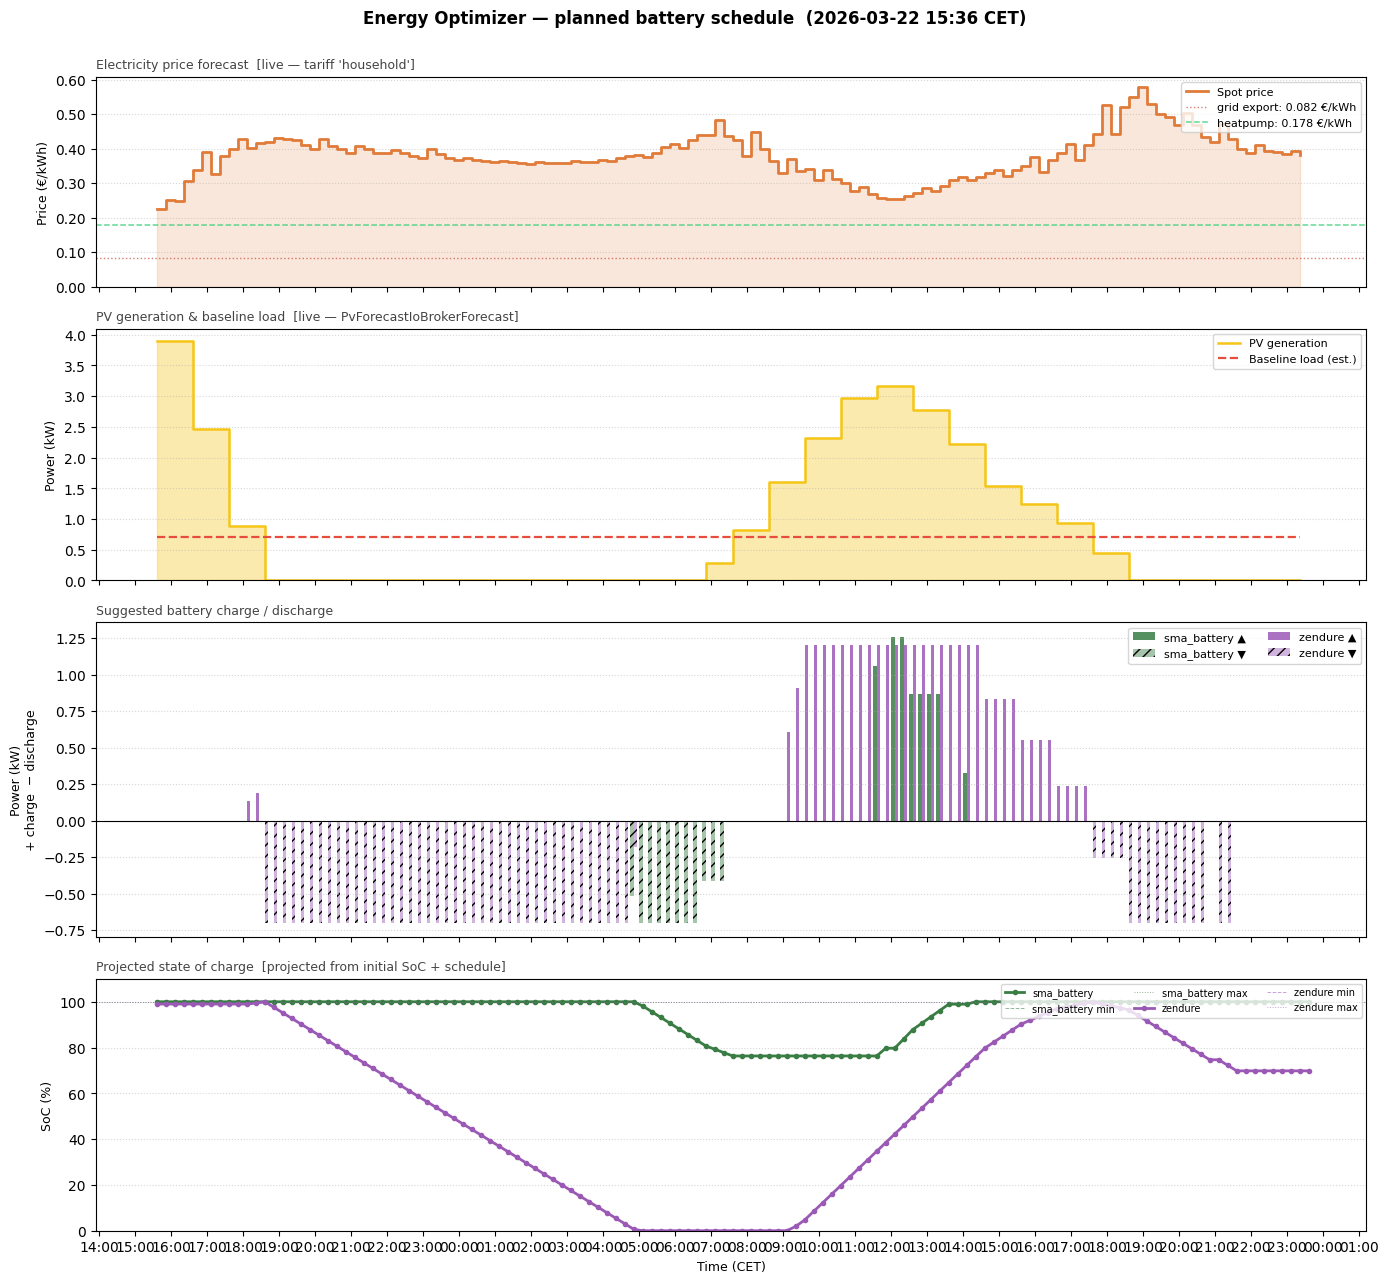

In [21]:
# ── Step 4: Diagram ───────────────────────────────────────────────────────────
# Renders the four-panel chart from the same LP variables as Step 3.
# The LP solution is converted to an EnergyPlan (same path as the real optimizer),
# then passed to the standard plot function.

from energy_assistant.core.models import EnergyPlan
from energy_assistant.plugins.milp_highs.optimizer import _extract_intents

intents = _extract_intents(storage_constraints, variables, timestamps, step_h)
plan    = EnergyPlan(horizon_hours=int(horizon.total_seconds() / 3600), intents=intents)
series  = _vo._extract_series(context, plan, timestamps, step_min)
_vo._plot(context, plan, series, price_src, pv_src, SAVE_PATH,
          tariffs=tariffs, step_min=step_min)
